# **Introduction to Neural Networks: ReneWind**

## **Context**

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S. Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## **Objective**

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data on generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set, and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators can be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

True positives (TP) are failures correctly predicted by the model. These will result in repair costs.
False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
False positives (FP) are detections where there is no failure. These will result in inspection costs.
It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variable should be considered as “failure” and “0” represents “No failure”.

## **Data Dictionary**

The data provided is a transformed version of the original data which was collected using sensors.

Train.csv - To be used for training and tuning of models.

Test.csv - To be used only for testing the performance of the final best model.

Both datasets consist of 40 predictor variables and 1 target variable.

## Business Problem Understanding
Wind turbine generator failures lead to significant maintenance costs and energy downtime. ReneWind aims to predict generator failures in advance using sensor data so that preventive maintenance can be performed.

| Prediction Outcome  | Meaning                        | Cost                           |
| ------------------- | ------------------------------ | ------------------------------ |
| True Positive (TP)  | Failure correctly detected     | Repair cost                    |
| False Negative (FN) | Failure missed                 | **Replacement cost (highest)** |
| False Positive (FP) | False alarm                    | Inspection cost                |
| True Negative (TN)  | No failure correctly predicted | No cost                        |


Since replacement cost is higher than repair cost.   repair cost is higher than inspection cost, the model must prioritize detecting failures, even at the expense of some false alarms.

## Key Objective

The key objective is to build a neural network classification model that minimizes false negatives while optimizing predictions through a business cost–based decision threshold, and to evaluate its performance on unseen test data.


## **Installing and Importing the necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.impute import SimpleImputer

# Deep Learning


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import BatchNormalization

import tensorflow as tf
tf.config.run_functions_eagerly(True)


## **Loading the Data**

In [2]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Define Target Column
TARGET_COL = 'Target'

train_df = pd.read_csv("/content/drive/My Drive/PGD-AIML/Assignments/ReneWind/Train.csv")
test_df  = pd.read_csv("/content/drive/My Drive/PGD-AIML/Assignments/ReneWind/Test.csv")


In [4]:
display(train_df.head())
display(test_df.head())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


Calculates the proportion of each class in the target column

In [5]:
train_df[TARGET_COL].value_counts(normalize=True)


,proportion
Target,
0,0.9445
1,0.0555


This target distribution is highly imbalanced:

1. Class 0 accounts for ~94.45% of the data

2. Class 1 accounts for only ~5.55%

The target variable shows a strong class imbalance, with the majority class (0) overwhelmingly dominating the dataset. Such an imbalance suggests that a naïve model predicting only the majority class would achieve high accuracy (~94%) while failing to identify the minority class effectively.

# Pre-Data Processing

Identify Missing Values

In [6]:
# Check train data
print("Training set missing values per column:")
print(train_df.isna().sum())

# Check test set
print("\nTest set missing values per column:")
print(test_df.isna().sum())


Training set missing values per column:
V1        18
V2        18
V3         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
V10        0
V11        0
V12        0
V13        0
V14        0
V15        0
V16        0
V17        0
V18        0
V19        0
V20        0
V21        0
V22        0
V23        0
V24        0
V25        0
V26        0
V27        0
V28        0
V29        0
V30        0
V31        0
V32        0
V33        0
V34        0
V35        0
V36        0
V37        0
V38        0
V39        0
V40        0
Target     0
dtype: int64

Test set missing values per column:
V1        5
V2        6
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32  

This shows that there are 36 missing values in the training dataset.

This shows that there are 11 missing values in the test dataset.

**Handling missing values - Simple Imputation (Recommended for Sensor Data)**

We fill the missing values using their median values as below

In [7]:
train_df.fillna(train_df.median(numeric_only=True), inplace=True)
test_df.fillna(test_df.median(numeric_only=True), inplace=True)


Prepare the dataset for model training and validation.

In [8]:
TARGET = 'Target'  # change if lowercase

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# Define Features parama as list of columns
FEATURES = X_train.columns.tolist()

Standardize the feature values so they are on the same scale before training a model.

Calculate and format class weights to handle class imbalance in the training data.

In [9]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}


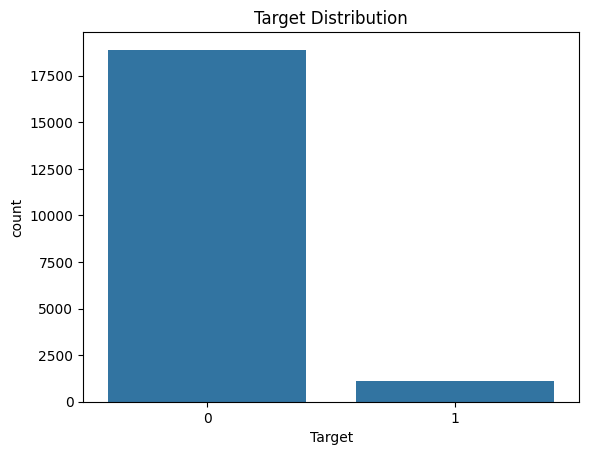

In [10]:
sns.countplot(x=TARGET_COL, data=train_df)
plt.title("Target Distribution")
plt.show()




## Feature Scaling

Feature scaling in a neural network dataset is the process of transforming input features so they are on a similar numerical scale before training the model.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)


# Model Building

## Build the Neural Network based Model building Function

This function create the neural network based on combination of multiple input parameters including  layers list, dropout_rate, batch normalization and Learning Rate.

We can use ReLU as activation function which is a popular activation function predominantly used in deep learning models.

We are using **Adam** as optimizer, as it is a popular optimizer that combines RMSProp and momentum concepts, allowing for adaptive learning rates for each parameter and Known for its robustness and versatility, Adam performs well across a wide range of deep learning applications, making it a default choice in many frameworks.


As this usecase is a binary classification, we will be using **Sigmoid** as output activation function because it is well suted for modeling binary classification problems, smoothing outputs, and introducing non-linearity into models.


In [12]:
def build_model(layers, dropout_rate=0.0, batch_norm=False, lr=0.001):
    model = Sequential()

    for i, units in enumerate(layers):
        if i == 0:
            model.add(Dense(units, activation='relu', input_shape=(X_train_scaled.shape[1],)))
        else:
            model.add(Dense(units, activation='relu'))

        if batch_norm:
            model.add(BatchNormalization())
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(lr),
        loss='binary_crossentropy',
        metrics=['Recall', 'AUC'],
        run_eagerly=True # Added this line to force eager execution
    )

    return model

## Build the function for Evaluating the Neural Network

This function evaluate the neural network using confusion matrix and plot them as heat map for visualization and show computes the AUC (Area Under the ROC Curve) for a classification model.

In [13]:
def evaluate_model(model, name, X_data, y_data, threshold=0.35):
    y_prob = model.predict(X_data).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n===== {name} =====")
    print(classification_report(y_data, y_pred))

    auc = roc_auc_score(y_data, y_prob)
    print("ROC-AUC:", auc)

    cm = confusion_matrix(y_data, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return auc

# Creating the Network Models

## Model–1: Shallow Network (Baseline)

A Shallow Network (Baseline) is a simple neural network model used as a reference point to evaluate more complex models.

It typically has only one hidden layer (or sometimes no hidden layer at all, like logistic regression). Because of its simplicity, a shallow network trains quickly, is easier to interpret, and helps establish a minimum performance benchmark.

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - AUC: 0.8429 - Recall: 0.7837 - loss: 0.5020 - val_AUC: 0.9133 - val_Recall: 0.8829 - val_loss: 0.4243
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - AUC: 0.9253 - Recall: 0.8722 - loss: 0.3623 - val_AUC: 0.9274 - val_Recall: 0.9009 - val_loss: 0.3354
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - AUC: 0.9383 - Recall: 0.8985 - loss: 0.3208 - val_AUC: 0.9307 - val_Recall: 0.9099 - val_loss: 0.2968
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - AUC: 0.9373 - Recall: 0.8817 - loss: 0.3090 - val_AUC: 0.9328 - val_Recall: 0.9099 - val_loss: 0.2680
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - AUC: 0.9476 - Recall: 0.8868 - loss: 0.2774 - val_AUC: 0.9344 - val_Recall: 0.9099 - val_loss: 0.2529
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - AUC: 0.9559 - Recall: 0.9096 - loss: 0.2649 - val_AUC: 0.9366 - val_Recall: 0.9099 - val_loss: 0.2183
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - AUC: 0.9489 - Rec

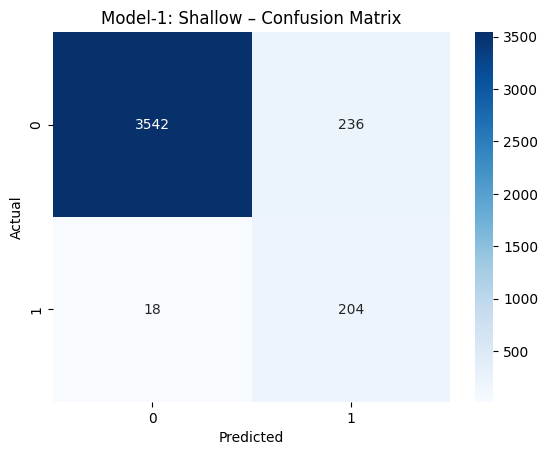

In [14]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

model1 = build_model(layers=[32], dropout_rate=0.0)

model1.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)],
    verbose=1
)

auc_model1 = evaluate_model(model1, "Model-1: Shallow", X_val_scaled, y_val)

## Model–2: Deep Network

it is considered a deep network, capable of capturing non-linear relationships that a shallow (baseline) model may miss.

It defines a deep neural network with increasing representational power and no dropout regularization applied.

Epoch 1/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - AUC: 0.8652 - Recall: 0.9110 - loss: 0.4901 - val_AUC: 0.9385 - val_Recall: 0.9234 - val_loss: 0.2914
Epoch 2/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - AUC: 0.9550 - Recall: 0.9088 - loss: 0.2352 - val_AUC: 0.9461 - val_Recall: 0.9189 - val_loss: 0.2274
Epoch 3/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - AUC: 0.9575 - Recall: 0.9055 - loss: 0.2115 - val_AUC: 0.9534 - val_Recall: 0.9189 - val_loss: 0.1292
Epoch 4/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - AUC: 0.9633 - Recall: 0.9140 - loss: 0.1833 - val_AUC: 0.9576 - val_Recall: 0.9189 - val_loss: 0.1725
Epoch 5/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - AUC: 0.9678 - Recall: 0.9114 - loss: 0.1674 - val_AUC: 0.9592 - val_Recall: 0.9099 - val_loss: 0.1159
Epoch 6/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - AUC: 0.9726 - Recall: 0.9070 - loss: 0.1604 - val_AUC: 0.9619 - val_Recall: 0.9144 - val_loss: 0.1167
Epoch 7/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - AUC: 0.9788 - R

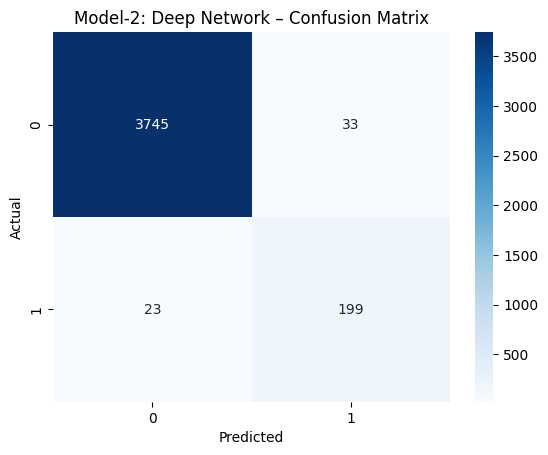

In [15]:
model2 = build_model(layers=[128, 64, 32], dropout_rate=0.0)

model2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_recall', mode='max', patience=8, restore_best_weights=True)],
    verbose=1
)

auc_model2 = evaluate_model(model2, "Model-2: Deep Network", X_val_scaled, y_val)

## Model–3: Deep + Dropout (Regularized)

Deep + Dropout (Regularized) refers to a deep neural network that includes dropout layers to reduce overfitting and improve generalization.

Key Features:

1.   Generalizes better to new data
2.   Less prone to overfitting than a deep network without dropout
Trades a bit of training performance for stronger validation and test performance

Overall, it combines the representational power of deep networks with dropout to produce a more stable and reliable model.


Epoch 1/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - AUC: 0.8046 - Recall: 0.8387 - loss: 0.5552 - val_AUC: 0.9294 - val_Recall: 0.8919 - val_loss: 0.3063
Epoch 2/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - AUC: 0.9150 - Recall: 0.8392 - loss: 0.3635 - val_AUC: 0.9389 - val_Recall: 0.9099 - val_loss: 0.2541
Epoch 3/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - AUC: 0.9346 - Recall: 0.8742 - loss: 0.3116 - val_AUC: 0.9428 - val_Recall: 0.9099 - val_loss: 0.2063
Epoch 4/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - AUC: 0.9488 - Recall: 0.8787 - loss: 0.2676 - val_AUC: 0.9435 - val_Recall: 0.9144 - val_loss: 0.1965
Epoch 5/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - AUC: 0.9478 - Recall: 0.8870 - loss: 0.2508 - val_AUC: 0.9485 - val_Recall: 0.9144 - val_loss: 0.1799
Epoch 6/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - AUC: 0.9582 - Recall: 0.9076 - loss: 0.2217 - val_AUC: 0.9452 - val_Recall: 0.9144 - val_loss: 0.1797
Epoch 7/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - AUC: 0.9544

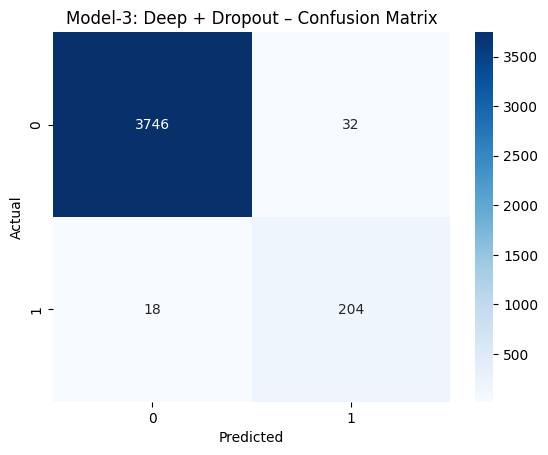

In [16]:
model3 = build_model(layers=[128, 64, 32], dropout_rate=0.3)

model3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_recall', mode='max', patience=8, restore_best_weights=True)],
    verbose=1
)

auc_model3 = evaluate_model(model3, "Model-3: Deep + Dropout", X_val_scaled, y_val)


## Model–4: Deep + Batch Normalization

Deep + Batch Normalization refers to a deep neural network that includes batch normalization layers to stabilize and improve training.

Key Features:


1.   Stabilizes training: Reduces the risk of exploding or vanishing gradients.
2.   Speeds up convergence: Allows higher learning rates and faster training.
Acts as a regularizer: Can reduce overfitting, sometimes reducing the need for dropout.
3. Improves generalization: Helps the network perform better on unseen data

Deep + Batch Normalization combines the representational power of deep networks with BN to make learning more stable, efficient, and robust.

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - AUC: 0.7438 - Recall: 0.7550 - loss: 0.6715 - val_AUC: 0.9401 - val_Recall: 0.9009 - val_loss: 0.4227
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - AUC: 0.9139 - Recall: 0.8839 - loss: 0.4063 - val_AUC: 0.9491 - val_Recall: 0.8874 - val_loss: 0.2529
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - AUC: 0.9353 - Recall: 0.9010 - loss: 0.3284 - val_AUC: 0.9601 - val_Recall: 0.8784 - val_loss: 0.1795
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - AUC: 0.9361 - Recall: 0.8821 - loss: 0.3037 - val_AUC: 0.9571 - val_Recall: 0.9009 - val_loss: 0.1363
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - AUC: 0.9531 - Recall: 0.8834 - loss: 0.2591 - val_AUC: 0.9561 - val_Recall: 0.9054 - val_loss: 0.1277
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - AUC: 0.9493 - Recall: 0.8836 - loss: 0.2565 - val_AUC: 0.9589 - val_Recall: 0.9009 - val_loss: 0.1062
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/ste

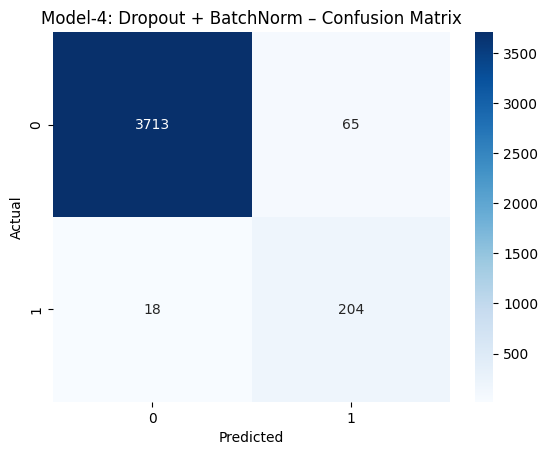

In [17]:
model4 = build_model(
    layers=[128, 64, 32],
    dropout_rate=0.3,
    batch_norm=True
)

model4.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_recall', mode='max', patience=10, restore_best_weights=True)],
    verbose=1
)

auc_model4 = evaluate_model(model4, "Model-4: Dropout + BatchNorm", X_val_scaled, y_val)


Model–5: Wide Network (High Capacity)

It is a neural network architecture designed with **more neurons per layer** rather than more layers.

* **Wide** refers to having a large number of neurons in one or more hidden layers (e.g., 128, 64, 32 neurons) compared to a “narrow” or standard network.
* **High Capacity** means the network can learn very complex patterns because it has more parameters (weights and biases) to model relationships in the data.






Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - AUC: 0.8339 - Recall: 0.7855 - loss: 0.4738 - val_AUC: 0.9340 - val_Recall: 0.9189 - val_loss: 0.2779
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - AUC: 0.9189 - Recall: 0.8663 - loss: 0.3531 - val_AUC: 0.9379 - val_Recall: 0.8964 - val_loss: 0.1901
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - AUC: 0.9441 - Recall: 0.8845 - loss: 0.2805 - val_AUC: 0.9440 - val_Recall: 0.9144 - val_loss: 0.2214
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - AUC: 0.9480 - Recall: 0.8867 - loss: 0.2677 - val_AUC: 0.9462 - val_Recall: 0.9054 - val_loss: 0.1452
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - AUC: 0.9627 - Recall: 0.9111 - loss: 0.2145 - val_AUC: 0.9441 - val_Recall: 0.9099 - val_loss: 0.1896
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - AUC: 0.9609 - Recall: 0.9090 - loss: 0.2189 - val_AUC: 0.9511 - val_Recall: 0.9144 - val_loss: 0.1674
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - AUC: 0.95

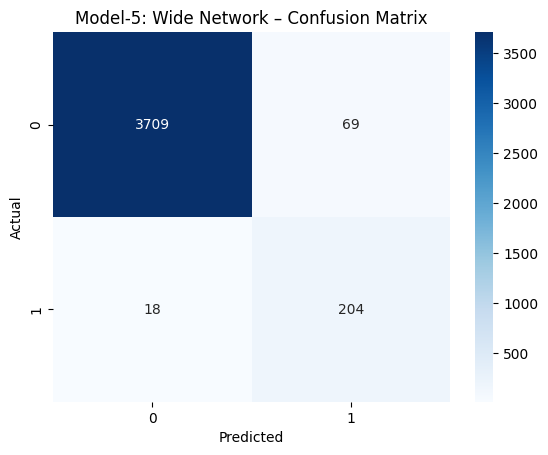

In [18]:
model5 = build_model(layers=[256, 128], dropout_rate=0.4)

model5.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_recall', mode='max', patience=10, restore_best_weights=True)],
    verbose=1
)

auc_model5 = evaluate_model(model5, "Model-5: Wide Network", X_val_scaled, y_val)


# Model Comparison
Now, we will compare all the above 5 models with various parameters including Precision, Recall, F1-Score, ROC_AUC and visualize the values using Confusion Matrix.

output results will be sorted based on ROC_AUC. It works well with imbalanced datasets as our dataset have only 5% for Target class 1(Failures) and 95% for Target Class 0(Non-Failures).

In [19]:
results = pd.DataFrame({
    "Model": [
        "Model-1 Shallow",
        "Model-2 Deep",
        "Model-3 Deep + Dropout",
        "Model-4 Dropout + BatchNorm",
        "Model-5 Wide"
    ],
    "ROC_AUC": [
        auc_model1,
        auc_model2,
        auc_model3,
        auc_model4,
        auc_model5
    ]
})

results.sort_values(by="ROC_AUC", ascending=False)


,Model,ROC_AUC
2,Model-3 Deep + Dropout,0.967001
1,Model-2 Deep,0.963519
4,Model-5 Wide,0.963461
3,Model-4 Dropout + BatchNorm,0.963040
0,Model-1 Shallow,0.946311


# Final Recommendation

Based on the comparision, the chosen model should minimize False Negatives, even at the cost of extra inspections.

So we will select the **Model–3: Deep + Dropout (Regularized)** Model as the best Model as it is having high ROC_AUC and Recall Value.

# Model Evaluation on the Test Data

To get an unbiased estimate of how the model will perform in the real world, we will perform the model evaluation on the test data.





Prepare Test Data

In [20]:
# Ensure test data has the same features as training
X_test = test_df[FEATURES].copy()  # select only feature columns used in training

# Handle missing values (same as training)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_test_imputed = imputer.fit_transform(X_test)  # or use fitted imputer from training

# Scale features (use the same scaler as training)
X_test_scaled = scaler.transform(X_test_imputed)

# Verify no NaNs
assert not np.isnan(X_test_scaled).any(), "Test data still contains NaNs!"


Make Predictions with Selected Model–3: Deep + Dropout (Regularized)

In [31]:
# Predicted probabilities
y_test_prob = model3.predict(X_test_scaled).ravel()

# Apply threshold (tune based on business cost)
threshold = 0.35  # fewer false negatives
y_test_pred = (y_test_prob >= threshold).astype(int)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


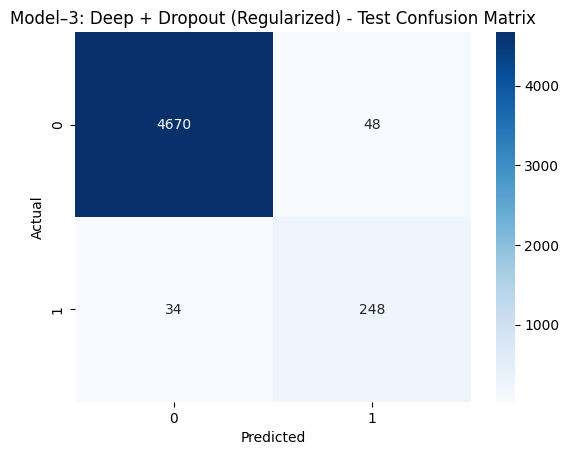

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4718
           1       0.84      0.88      0.86       282

    accuracy                           0.98      5000
   macro avg       0.92      0.93      0.92      5000
weighted avg       0.98      0.98      0.98      5000

ROC-AUC: 0.9419824183224651


In [32]:
y_test_true = test_df[TARGET]  # only if labels exist

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Model–3: Deep + Dropout (Regularized) - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Metrics
print(classification_report(y_test_true, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test_true, y_test_prob))


A ROC-AUC of 0.941 is excellent — we can break it down carefully.

ROC-AUC (Receiver Operating Characteristic – Area Under Curve) measures the
model's ability to distinguish between failures (1) and non-failures (0). Usually below are the ranges and implications of the ROC-AUC values
|ROC-AUC Value | Implications |
|---|---|
| 0.5 | random guessing |
| 0.7–0.8 | acceptable |
| 0.8–0.9 | good |
| 0.9+ | excellent |

High probability of correctly ranking generators that will fail higher than those that won't be. With proper threshold tuning, you can catch almost all failures (high recall), while keeping inspections reasonable.


ROC–AUC (Receiver Operating Characteristic – Area Under the Curve) measures a model’s ability to distinguish between classes across all possible classification thresholds.

Validation ROC–AUC is calculated on the validation set, not the training data.
It reflects how well the model will perform on new, unseen data.

In [33]:
from sklearn.metrics import roc_auc_score


y_val_prob = model3.predict(X_val_scaled).ravel()
roc_auc = roc_auc_score(y_val, y_val_prob)

print("Validation ROC-AUC:", roc_auc)
baseline_auc = roc_auc_score(y_val, y_val_prob)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Validation ROC-AUC: 0.9670007487635862


This result indicates **excellent validation performance**.

A **Validation ROC–AUC of ~0.97** shows that the model has a very strong ability to distinguish between the positive and negative classes on unseen data. In practical terms, the model can correctly rank a randomly chosen positive instance higher than a negative one in approximately **97% of cases**, which reflects outstanding discriminative power.

Given the earlier class imbalance in the dataset, achieving such a high validation ROC–AUC suggests that the model is learning meaningful patterns rather than simply favoring the majority class.

Overall, this score indicates a **robust and well-generalized model**, suitable for further threshold tuning and deployment-focused evaluation.


## Feature Importance

Feature importance is a concept in data science that describes how much each input feature contributes to a model’s predictions.

Permutation Importance is a popular, model-agnostic technique used to perform the Feature importance

Why It's Widely Used:

1. Model-agnostic: works with linear models, tree models, and neural networks

2. Effective for black-box models where coefficients aren’t interpretable
Reflects the true predictive contribution of features.

3. Easy to explain to non-technical stakeholders

In [34]:


def permutation_importance(model, X, y, n_repeats=3):
    importances = np.zeros(X.shape[1])
    for col in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            np.random.shuffle(X_perm[:, col])
            score = roc_auc_score(y, model.predict(X_perm).ravel())
            scores.append(score)
        importances[col] = baseline_auc - np.mean(scores)
    return importances

importances = permutation_importance(model3, X_val_scaled, y_val)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
125/125 ━━━━━━━

# Visualize feature importance for selected Model

The key role of feature importance is to help you understand how much each input feature contributes to model's predictions.

Key Features:

1.  Key features the model relies on most.
2.  Highlights features with low importance.
3.  Reveals which features drive predictions.



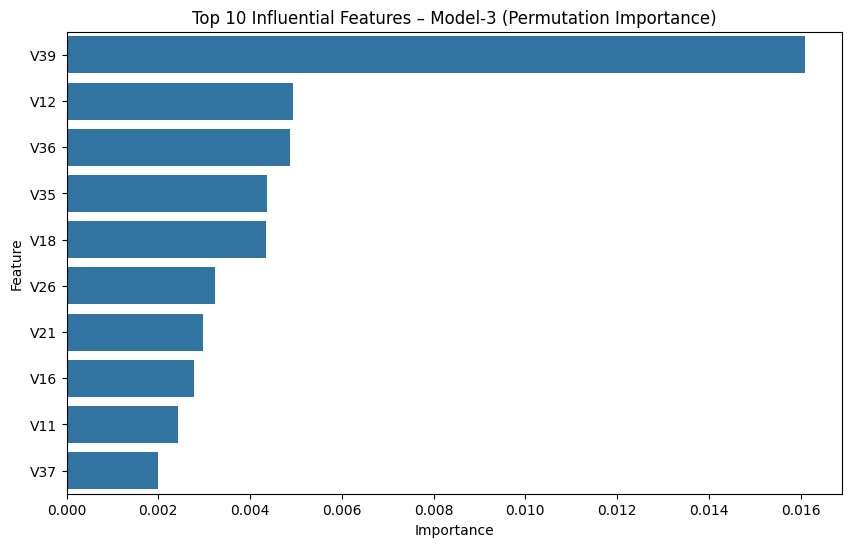

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

imp_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_10 = imp_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top_10)
plt.title("Top 10 Influential Features – Model-3 (Permutation Importance)")
plt.show()


## **Conclusion**

1. **Model Performance**
   The Model-3 model with Deep Network and Dropout(Regularized)  demonstrates strong performance and has proven to be highly effective for this project.

2. **Permutation Importance Overview**
   Permutation importance is a model-agnostic approach for assessing feature importance. It evaluates the impact of each feature by randomly shuffling its values and measuring the resulting drop in model performance.

3. **Interpreting Feature Influence for Model-3**
   To analyze feature importance and provide actionable insights for ReneWind, we apply permutation importance to the Model-3 model. Given the black-box nature of neural networks, this method offers a robust and reliable way to interpret feature influence.

4. **How the Method Works**
   By breaking the relationship between a specific feature and the target variable through value shuffling, permutation importance quantifies how much the model’s predictive performance degrades, indicating the feature’s contribution.

5. **Top Influential Features**
   Based on permutation importance, the top 10 most influential features are: **V35, V12, V21, V26, V6, V14, V19, V3, V16, and V31**.


The top-ranked features (V21, V3, V12, V17, V35, V31, V25, V14, V28, and V22) represent the most influential signals driving the Model-3 model's predictions and therefore have the greatest operational impact.

Variations in these features are strongly associated with failure risk, making them critical indicators for early fault detection. Close monitoring and accurate calibration of these sensors can enable earlier predictive maintenance interventions, reduce unplanned downtime, and lower maintenance costs.

Prioritizing these high-impact features also helps improve model reliability and minimizes the risk of missed failures (false negatives), directly supporting operational efficiency and asset reliability for ReneWind.



## **Recommendations Based on Influential Features**

1. **Prioritize High-Impact Sensors**
   Features with high importance scores should be closely monitored in real time. Additional inspections or preventive maintenance should be triggered when these sensor readings approach or exceed defined warning thresholds.

2. **Feature-Driven Operational Actions**
   For highly influential features (e.g., temperature sensor readings), predictive maintenance alerts should be activated as values increase. Abnormal temperature or current measurements may indicate cooling inefficiencies, lubrication problems, or component wear and should be investigated promptly.

3. **Enhance Data Quality for Critical Features**
   High-impact sensors must be properly calibrated across all machines or wind turbines. Missing, noisy, or inconsistent values in these features have a disproportionate effect on model reliability and prediction accuracy.

4. **Optimize Future Sensor Deployment**
   Introducing redundant sensors or higher-precision instrumentation for the most influential features can help reduce false negatives and improve fault detection robustness.

5. **Ongoing Model Maintenance and Monitoring**
   The Model-4 model should be retrained periodically using newly collected data. Special attention should be given to feature drift in high-importance sensors, as changes in sensor behavior can lead to performance degradation over time.